# Compare Global Views from Three TFRecord Files

This notebook loads three different TFRecord files and compares the global views from the first 10 examples in each dataset.


In [ ]:
# %pip install --upgrade pip
# %pip install tensorflow
# import sys; print(sys.executable)  # sanity check: which Python the kernel is using
# import tensorflow as tf; print(tf.__version__)

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
/Users/pablom.perez/miniconda3/envs/sci-py312/bin/python
2.20.0


In [11]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Define the three file paths
files_april = '/Users/pablom.perez/Desktop/MIT-PhD-macbook/Astronet2025/data/00000-of-00005'
files_oct25 = '/Users/pablom.perez/Desktop/MIT-PhD-macbook/Astronet2025/data/00000-of-00050'
files_oct25_cadencebin = '/Users/pablom.perez/Desktop/MIT-PhD-macbook/Astronet2025/data/00000-of-00050-cadencebin'

# List of file paths and their labels
file_paths = [files_april, files_oct25, files_oct25_cadencebin]
file_labels = ['April', 'Oct25', 'Oct25_CadenceBin']

print("File paths defined:")
for i, (path, label) in enumerate(zip(file_paths, file_labels)):
    print(f"{i+1}. {label}: {path}")


File paths defined:
1. April: /Users/pablom.perez/Desktop/MIT-PhD-macbook/Astronet2025/data/00000-of-00005
2. Oct25: /Users/pablom.perez/Desktop/MIT-PhD-macbook/Astronet2025/data/00000-of-00050
3. Oct25_CadenceBin: /Users/pablom.perez/Desktop/MIT-PhD-macbook/Astronet2025/data/00000-of-00050-cadencebin


In [12]:
def load_tfrecord_examples(file_path, num_examples=10):
    """
    Load the first num_examples from a TFRecord file and extract global_view data.

    Args:
        file_path (str): Path to the TFRecord file
        num_examples (int): Number of examples to load

    Returns:
        list: List of global_view arrays for each example
    """
    global_views = []
    astro_ids = []

    try:
        raw_dataset = tf.data.TFRecordDataset([file_path])

        for i, raw_record in enumerate(raw_dataset.take(num_examples)):
            example = tf.train.Example()
            example.ParseFromString(raw_record.numpy())

            # Extract global_view
            if 'global_view' in example.features.feature:
                global_view = list(example.features.feature['global_view'].float_list.value)
                global_views.append(np.array(global_view))
            else:
                print(f"Warning: global_view not found in example {i}")
                global_views.append(None)

            # Extract astro_id for reference - following original code pattern
            if 'astro_id' in example.features.feature:
                astro_id_bytes = example.features.feature['astro_id'].bytes_list.value
                if len(astro_id_bytes) > 0:
                    # Decode all bytes and join them (following original code pattern)
                    astro_id = ''.join([v.decode("utf-8") for v in astro_id_bytes])
                    astro_ids.append(astro_id)
                else:
                    astro_ids.append(f"example_{i}")
            else:
                astro_ids.append(f"example_{i}")

    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return [], []

    return global_views, astro_ids

print("Function defined to load TFRecord examples")


Function defined to load TFRecord examples


In [13]:
# Load data from all three files
all_global_views = []
all_astro_ids = []

print("Loading data from all three TFRecord files...")
for i, (file_path, label) in enumerate(zip(file_paths, file_labels)):
    print(f"\nLoading {label} ({file_path})...")
    global_views, astro_ids = load_tfrecord_examples(file_path, num_examples=10)
    all_global_views.append(global_views)
    all_astro_ids.append(astro_ids)
    print(f"Loaded {len(global_views)} examples from {label}")

print(f"\nData loading complete!")
print(f"Total datasets: {len(all_global_views)}")
for i, (views, ids) in enumerate(zip(all_global_views, all_astro_ids)):
    print(f"Dataset {i+1} ({file_labels[i]}): {len(views)} examples")


Loading data from all three TFRecord files...

Loading April (/Users/pablom.perez/Desktop/MIT-PhD-macbook/Astronet2025/data/00000-of-00005)...
Loaded 10 examples from April

Loading Oct25 (/Users/pablom.perez/Desktop/MIT-PhD-macbook/Astronet2025/data/00000-of-00050)...
Loaded 10 examples from Oct25

Loading Oct25_CadenceBin (/Users/pablom.perez/Desktop/MIT-PhD-macbook/Astronet2025/data/00000-of-00050-cadencebin)...
Loaded 10 examples from Oct25_CadenceBin

Data loading complete!
Total datasets: 3
Dataset 1 (April): 10 examples
Dataset 2 (Oct25): 10 examples
Dataset 3 (Oct25_CadenceBin): 10 examples


2025-10-23 15:54:01.984363: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-10-23 15:54:01.993659: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [14]:
def plot_global_view_comparison(example_idx):
    """
    Plot global views from all three datasets for a specific example.

    Args:
        example_idx (int): Index of the example to plot (0-9)
    """
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    for i, (views, label) in enumerate(zip(all_global_views, file_labels)):
        if example_idx < len(views) and views[example_idx] is not None:
            axes[i].plot(views[example_idx], linewidth=1)
            axes[i].set_title(f'{label}\nAstro ID: {all_astro_ids[i][example_idx]}')
            axes[i].set_xlabel('Time Index')
            axes[i].set_ylabel('Flux')
            axes[i].grid(True, alpha=0.3)
            axes[i].set_ylim(-1.05, 0.3)
        else:
            axes[i].text(0.5, 0.5, f'No data available\nfor example {example_idx}',
                        ha='center', va='center', transform=axes[i].transAxes)
            axes[i].set_title(f'{label} - No Data')

    plt.suptitle(f'Global View Comparison - Example {example_idx + 1}', fontsize=14)
    plt.tight_layout()
    plt.show()

print("Function defined to plot global view comparisons")


Function defined to plot global view comparisons


Generating comparison plots for all examples...

Plotting example 1...


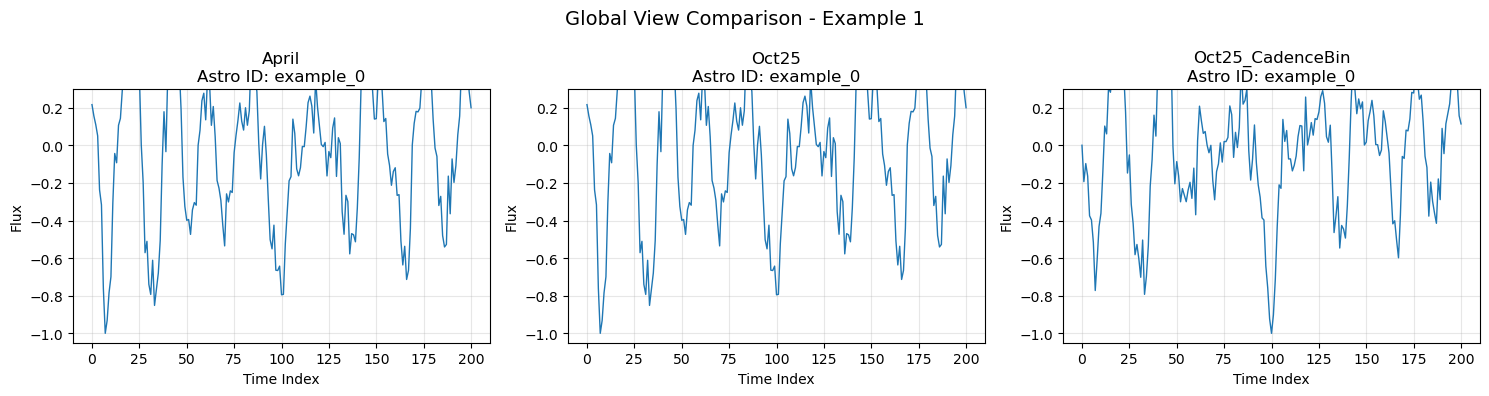


Plotting example 2...


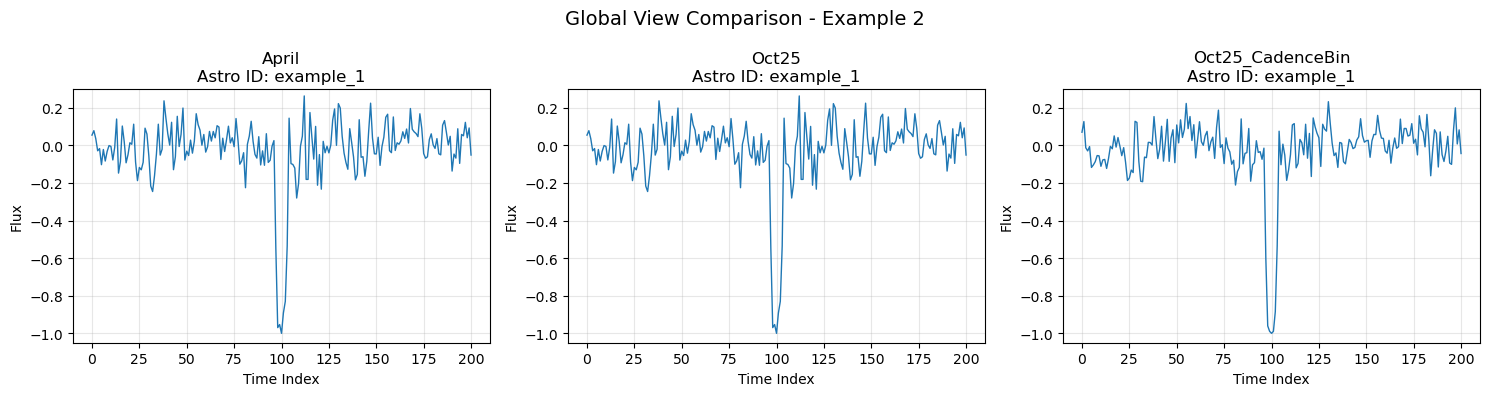


Plotting example 3...


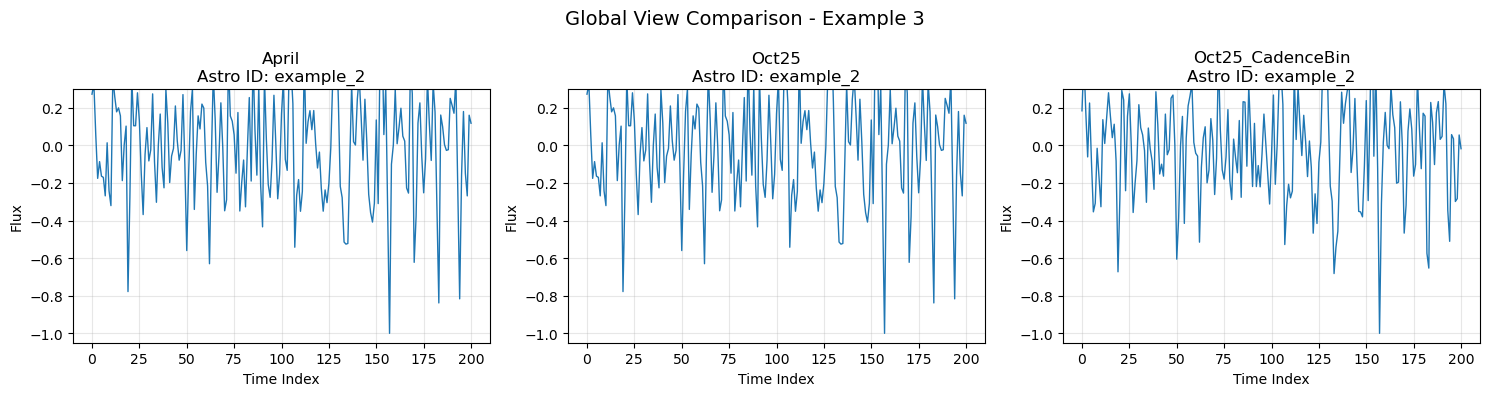


Plotting example 4...


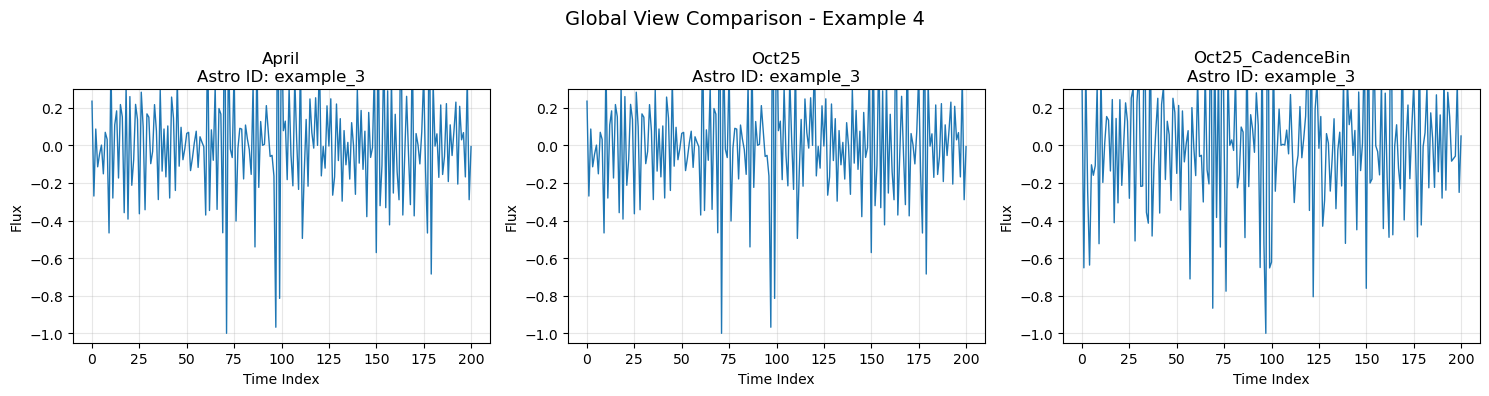


Plotting example 5...


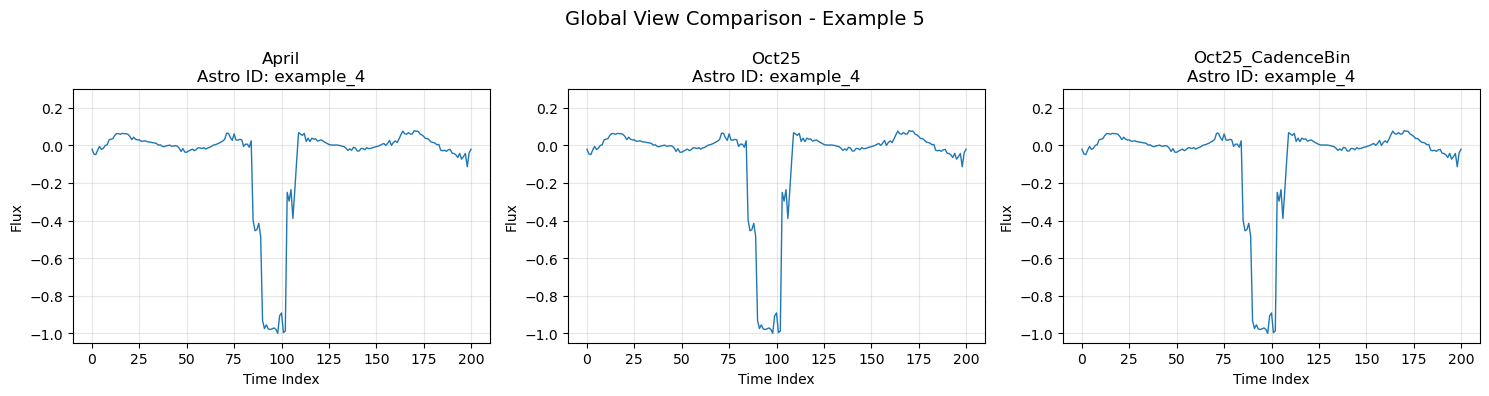


Plotting example 6...


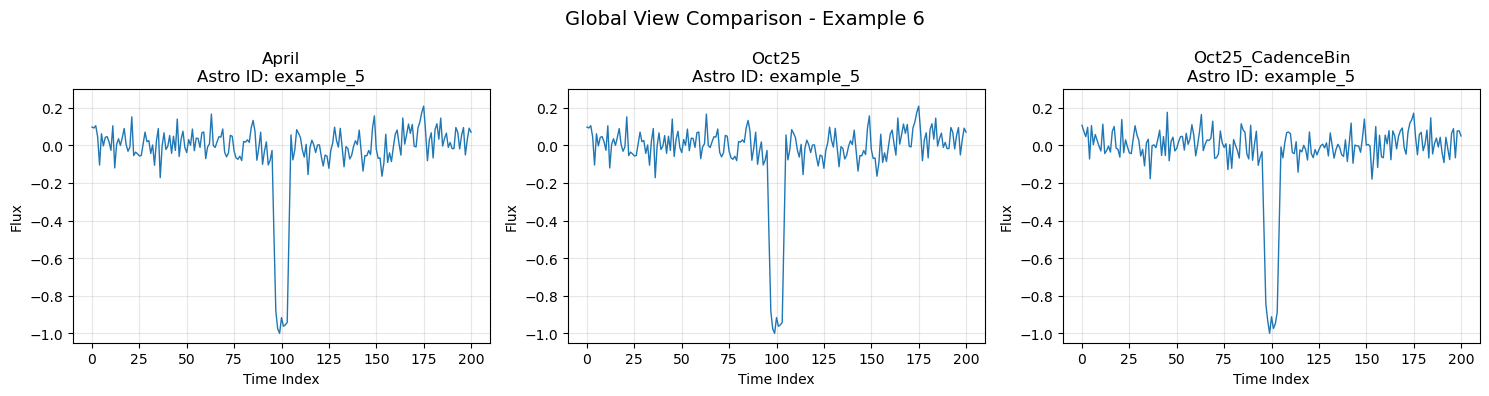


Plotting example 7...


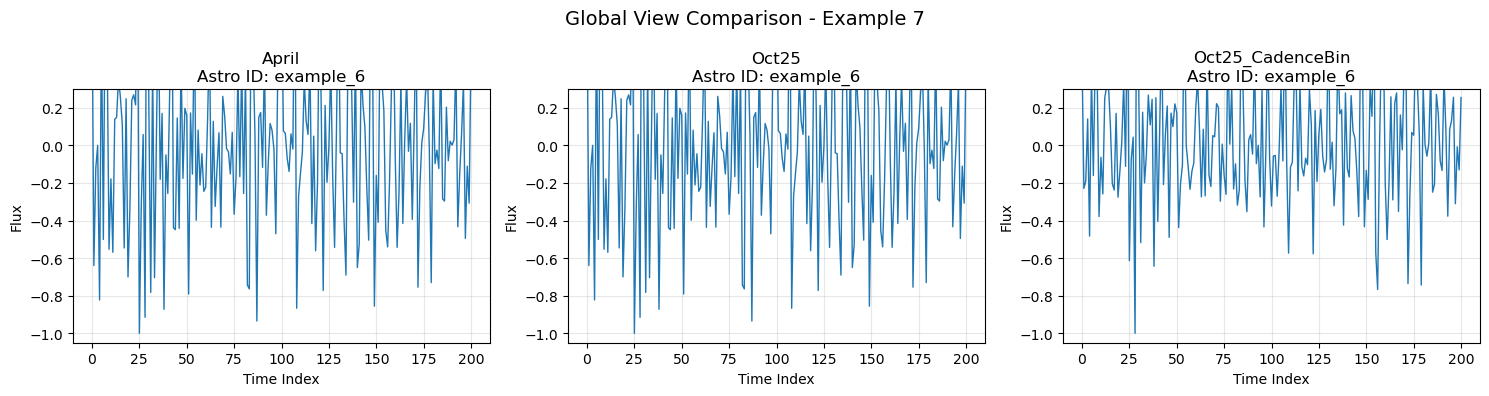


Plotting example 8...


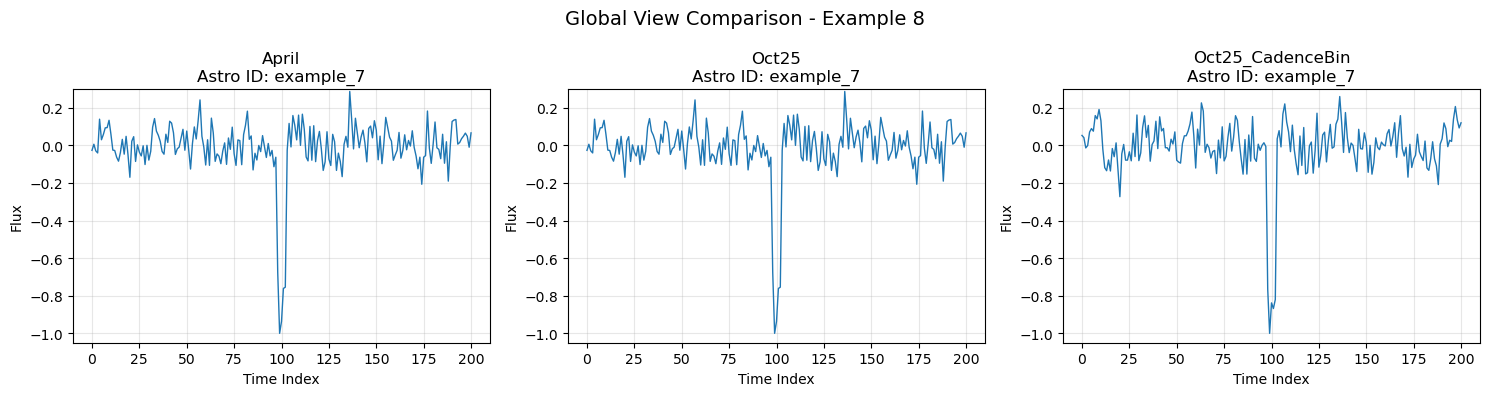


Plotting example 9...


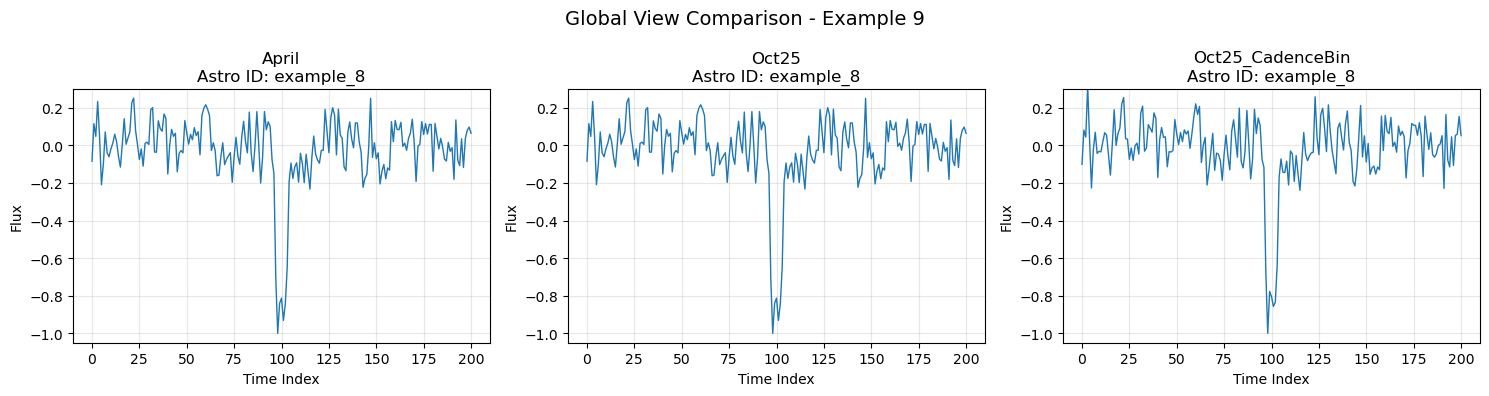


Plotting example 10...


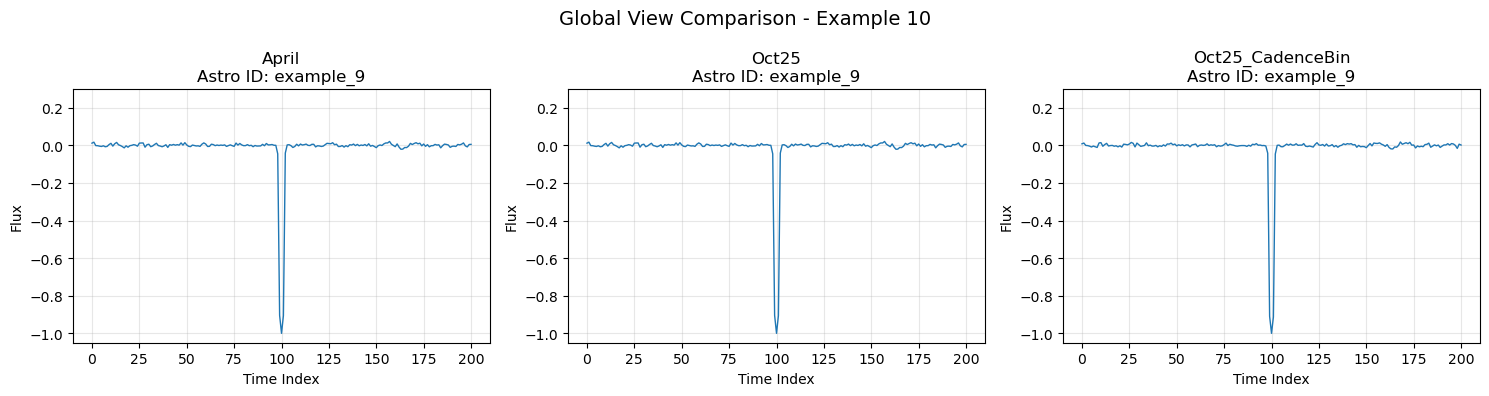

In [15]:
# Generate comparison plots for all 10 examples
print("Generating comparison plots for all examples...")

for example_idx in range(10):
    print(f"\nPlotting example {example_idx + 1}...")
    plot_global_view_comparison(example_idx)


## Summary

This notebook has loaded the first 10 examples from each of the three TFRecord files and generated comparison plots showing the global views side by side. Each plot shows:

1. **April dataset**: Global view from the April TFRecord file
2. **Oct25 dataset**: Global view from the October 25 TFRecord file  
3. **Oct25_CadenceBin dataset**: Global view from the October 25 CadenceBin TFRecord file

The plots allow you to visually compare how the global views differ between the different datasets for the same examples.
